# L00 · 15분 OPD 체험과 전체 지도

## Goal

**예상 시간:** 20분 · **경로:** fast, full

- 전체 학습 지도를 읽는다
- SFT와 OPD의 첫 차이를 실행한다
- 빠른/전체 경로를 고른다

### 전체 지도

```mermaid
flowchart LR
  D[Prompt/Data] --> R{State source}
  R --> SFT[SFT]; R --> KD[Off-policy KD]; R --> OPD[Student rollout / OPD]
  OPD --> T[Teacher score] --> L[Masked loss] --> U[Student update] --> E[Evaluation]
  OPD --> G[GKD / vOPD / OPD2]; OPD --> M[Multi-turn: TCOD / SOD / SAGE]
```

```text
Prompt/Data -> fixed hard labels: SFT
            -> fixed teacher traces: off-policy KD
            -> current student rollout: OPD -> teacher score -> masked loss -> update
               -> GKD / vOPD / OPD2 / multi-turn TCOD-SOD-SAGE
All routes -> fair evaluation: accuracy, agreement, KL, overlap, avg@K, pass@K
```

Alt text: Three state sources lead to SFT, off-policy KD, or a student-rollout OPD loop; OPD branches into GKD, variance/delta methods, and multi-turn stabilization before fair evaluation.

## Setup

In [1]:
LESSON_ID = "L00"
from pathlib import Path
import sys
import torch

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root / "src"))

import opd_study
from opd_study.device import resolve_device
from opd_study.utils import seed_everything

seed_everything(42)
device_report = resolve_device("cpu")
print({"lesson": LESSON_ID, "opd_study": opd_study.__version__,
       "torch": torch.__version__, "device": device_report.selected,
       "profile": "toy", "network": "not required"})

{'lesson': 'L00', 'opd_study': '0.1.0.dev0', 'torch': '2.13.0', 'device': 'cpu', 'profile': 'toy', 'network': 'not required'}


## Steps

### 1/3 · 8–12 min

먼저 전체 루프를 한 번 본다. 아래 곡선은 대형 모델 성능이 아니라, 같은 초기 분포에서 hard-label SFT와 teacher 분포를 따르는 OPD 목적이 서로 다르다는 현미경 예제다.

그림 대체 설명: 출력의 label과 숫자는 색 없이도 읽을 수 있다.

### 핵심 원리

OPD를 한 문장으로 줄이면 **현재 student가 만든 prefix에서 teacher 분포를 묻고 student만 업데이트하는 증류**다. SFT는 고정 정답 궤적, off-policy KD는 고정 prefix의 teacher 분포, OPD는 현재 student가 실제로 방문한 prefix를 학습 state로 쓴다.

OPD는 reward를 최대화하는 RL과 같지 않다. sampling은 학습할 state를 바꾸지만 supervision은 teacher의 조건부 token 분포다. 따라서 핵심 질문은 늘 네 가지다: *누가 state를 만들었나? teacher가 무엇을 반환했나? 어떤 token을 mask했나? gradient가 어디로 흐르나?*

### 실제 구현: 왜 이렇게 만들었나

| 경로 | state 생성자 | target | 핵심 위험 |
|---|---|---|---|
| SFT | dataset/teacher trace | hard token | inference state 불일치 |
| off-policy KD | 고정 prefix | teacher full distribution | 오류 state 미관찰 |
| OPD | current student | teacher distribution/score | sampling 분산·나쁜 state |

실제 루프: [`losses.py`](../../src/opd_study/algorithms/losses.py), [`rollout.py`](../../src/opd_study/algorithms/rollout.py).

In [2]:
import inspect
from opd_study.algorithms import on_policy_distillation_loss

objects_to_show = (on_policy_distillation_loss,)
for object_to_show in objects_to_show:
    source_lines = inspect.getsource(object_to_show).splitlines()
    print(f"\n# {object_to_show.__module__}.{object_to_show.__qualname__}")
    print("\n".join(source_lines[:80]))
    if len(source_lines) > 80:
        print(f"... {len(source_lines) - 80} more lines; open the linked source file")


# opd_study.algorithms.losses.on_policy_distillation_loss
def on_policy_distillation_loss(
    student_logits: Tensor,
    trajectories: TrajectoryBatch,
    signals: TeacherSignals,
    *,
    estimator: str = "full_reverse_kl",
    beta: float = 1.0,
    temperature: float = 1.0,
) -> LossOutput:
    """OPD objective evaluated on trajectories sampled from the current student."""

    if not math.isfinite(temperature) or temperature <= 0:
        raise ValueError("temperature must be finite and positive")
    if estimator == "full_reverse_kl":
        return generalized_kd_loss(
            student_logits,
            trajectories,
            signals,
            beta=beta,
            temperature=temperature,
        )
    if estimator == "sampled_reverse_kl":
        if temperature != 1.0:
            raise ValueError("sampled_reverse_kl currently requires temperature=1")
        return sampled_reverse_kl_loss(student_logits, trajectories, signals)
    raise ValueError("estimator 

### 다른 선택지는 없나?

**언제 무엇을 쓰나?** 정답 trace가 충분하면 SFT가 가장 단순하다. 고정 prefix에서 teacher의 dark knowledge가 필요하면 off-policy KD, inference 중 오류 state까지 교정하려면 OPD를 고려한다. OPD가 언제나 우월하다는 전제는 두지 않는다.

### 2/3 · 실행하고 관찰하기

실행 전 예측: L00의 첫 출력에서 가장 먼저 확인해야 할 invariant는 무엇일까? 한 문장으로 적고 실행한다.

In [3]:
from opd_study.math import reverse_kl_from_logits

teacher_logits = torch.log(torch.tensor([0.70, 0.20, 0.10]))
initial_logits = torch.tensor([0.0, 0.0, 0.0])

def fit(objective: str) -> list[float]:
    logits = torch.nn.Parameter(initial_logits.clone())
    optimizer = torch.optim.SGD([logits], lr=0.8)
    history = []
    for _ in range(8):
        loss = (-torch.log_softmax(logits, -1)[0] if objective == "sft"
                else reverse_kl_from_logits(teacher_logits, logits))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        history.append(float(loss.detach()))
    return history

curves = {name: fit(name) for name in ("sft", "opd")}
print({name: [round(value, 3) for value in values] for name, values in curves.items()})

{'sft': [1.099, 0.641, 0.412, 0.292, 0.224, 0.18, 0.15, 0.128], 'opd': [0.324, 0.171, 0.084, 0.042, 0.022, 0.012, 0.007, 0.004]}


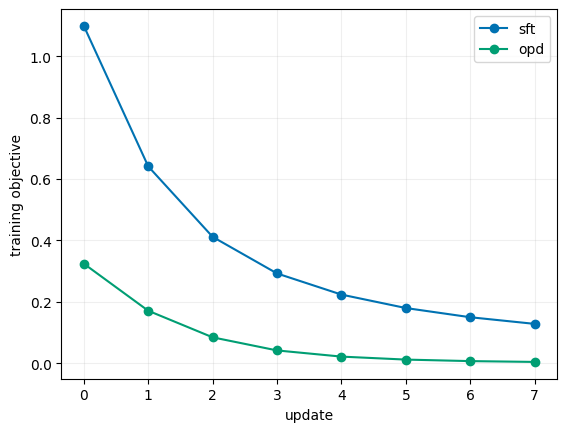

In [4]:
import matplotlib.pyplot as plt

for name, color in (("sft", "#0072B2"), ("opd", "#009E73")):
    plt.plot(curves[name], marker="o", label=name, color=color)
plt.xlabel("update"); plt.ylabel("training objective"); plt.legend(); plt.grid(alpha=.2)
plt.show()

## Checks

In [5]:
assert curves["sft"][-1] < curves["sft"][0]
assert curves["opd"][-1] < curves["opd"][0]
assert curves["sft"] != curves["opd"]
print("check passed: same initialization, different objectives, both decrease")

check passed: same initialization, different objectives, both decrease


**연습 (5분):** 같은 초기 logits에서 teacher가 `[0.45, 0.45, 0.10]`일 때 hard-label SFT와 reverse-KL OPD가 첫 두 token을 어떻게 다르게 다룰지 실행 전에 적고 확인하라.

<details><summary>확인 기준</summary>SFT는 선택한 hard target 하나만 직접 올리지만 OPD는 첫 두 token에 teacher가 둔 질량을 함께 반영한다고 설명하면 된다.</details>

## 내가 자주 틀리는 것

### M1 — OPD를 reward optimization으로 부르기

- 틀린 형태: student sample에 점수를 주니 곧바로 RL이라고 한다.
- 왜 틀렸나: 여기 supervision은 teacher token 분포이며 reward objective가 아니다.
- 고친 형태: state source와 target source를 분리해 말한다.
- 관련 검사: `test_teacher_is_frozen_and_student_updates`

### M2 — toy loss 감소를 benchmark 승리로 해석하기

- 틀린 형태: 8번 update 곡선으로 OPD가 SFT보다 낫다고 결론낸다.
- 왜 틀렸나: 서로 다른 objective의 배관만 확인한다.
- 고친 형태: 같은 budget의 held-out accuracy·agreement와 한계를 함께 본다.
- 관련 검사: `test_demo_writes_all_learner_facing_artifacts`

## 60초 요약

1. 전체 학습 지도를 읽는다
2. SFT와 OPD의 첫 차이를 실행한다
3. 빠른/전체 경로를 고른다

## Next Steps

다음 노트북으로 가기 전, 위 assertion을 다시 실행하고 틀린 예측 한 줄을 남긴다.

### Sources

- [`gkd`](https://arxiv.org/abs/2306.13649v3) · `2306.13649v3` · license `CC-BY-4.0` · [audited manifest](../../docs/sources.yml)